In [1]:
import torch
import numpy as np
import os
import xarray as xr 
import matplotlib.pyplot as plt 
import matplotlib.colors as mcolors

from scipy.stats import pearsonr, spearmanr
from torchmetrics.image import StructuralSimilarityIndexMeasure
from scipy.stats import exponweib
import seaborn as sns
from scipy.optimize import curve_fit


In [2]:
preds_dir = '../../preds/'
dataset_dir = '../../data/all_years_merged_era5.nc'

SCALING_FACTOR = 4
TEST_YEAR = 1984
TRAIN_START = '1980-01-01'
TRAIN_END = '1982-12-31'
years = [i for i in range(1984, 2024)]
print(years)


[1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]


In [3]:
def load_dataset(data, start, end, patch_size):
    dataset = xr.open_dataset(data).sel(valid_time=slice(start, end)).isel(
        longitude=slice(0, patch_size), latitude=slice(0, patch_size))
    return dataset

def normalize_data(data, custom_scale = None):
    returned_scale = {}
    for var in data:
        
        if custom_scale and var in custom_scale:
            min_val = custom_scale[var]['min']
            max_val = custom_scale[var]['max']
        else:
            min_val = data[var].values.min()
            max_val = data[var].values.max()
            
            returned_scale[var] = {'min': min_val, 'max': max_val}
            
            
        data[var] = (data[var] - min_val) / (max_val - min_val)
        
        
    return data, returned_scale


def average_pooling(data, scale, to_int=False):
    new_h, new_w = data.shape[0] // scale, data.shape[1] // scale
    data = data.reshape(new_h, scale, new_w, scale).mean(axis=(1, 3))
    if to_int:
        data = np.uint8(data)
    return data

def get_original_wind_speed(data, scale):
    u_min = scale['u10']['min'].item()
    u_max = scale['u10']['max'].item()
    v_min = scale['v10']['min'].item()
    v_max = scale['v10']['max'].item()
    
    norm_u = data[:,0,:,:]
    norm_v = data[:,1,:,:]
    
    u = norm_u * (u_max - u_min) + u_min
    v = norm_v * (v_max - v_min) + v_min


    return torch.sqrt(u**2 + v**2)


def mse(pred, target):
    return ((pred - target) ** 2).mean()
def mae(pred, target):
    return (np.abs(pred - target)).mean()


def get_metrics(preds, target):
    if isinstance(preds, torch.Tensor):
        preds = preds.numpy()
    mse_val = mse(preds, target)
    mae_val = mae(preds, target)
    return mse_val, mae_val


def get_skill_score(model_score, baseline_score):
    return 1 - (model_score / baseline_score)


def get_descriptive_stats(data):
    return data.mean(), data.std(), data.min(), data.max()


def get_SSIM(preds, target):
    if isinstance(preds, torch.Tensor):
        preds = preds.clone().detach().unsqueeze(0).unsqueeze(0)
        target = target.clone().detach().unsqueeze(0).unsqueeze(0)
    else:
        preds = torch.tensor(preds).unsqueeze(0).unsqueeze(0)
        target = torch.tensor(target).unsqueeze(0).unsqueeze(0)
    ssim = StructuralSimilarityIndexMeasure()
    return ssim(preds, target)

def get_correlation(preds, target, method='pearson'):
    preds = preds.flatten()
    target = target.flatten()
    if method == 'spearman':
        return spearmanr(preds, target)
    else:
        return pearsonr(preds, target)



In [4]:
def get_ground_truth_ws(data_dir, train_start,train_end, test_year):
    dataset = load_dataset(data_dir, start=train_start, end=f'{test_year}-12-31', patch_size=32)
    train_split = dataset.sel(valid_time=slice(train_start, train_end))
    test_split = dataset.sel(valid_time=slice(f'{test_year}-01-01', f'{test_year}-12-31'))
    _, scale = normalize_data(train_split)
    gt_ws = np.sqrt(test_split['u10'].values**2 + test_split['v10'].values**2)
    return test_split, gt_ws, scale

eval_split, ground_truth_wind_speeds, scale = get_ground_truth_ws(data_dir=dataset_dir,
                                                                    train_start=TRAIN_START,
                                                                    train_end=TRAIN_END,
                                                                    test_year=TEST_YEAR)


In [5]:
def get_low_res_ws(test_data, scaling_factor):
    u10, v10 = [], []
    for i in range(test_data['u10'].shape[0]):
        u10.append(average_pooling(test_data['u10'][i].values, scaling_factor, False))
        v10.append(average_pooling(test_data['v10'][i].values, scaling_factor, False))
    u10 = np.array(u10)
    v10 = np.array(v10)
    lr_ws = np.sqrt(u10**2 + v10**2)
    return lr_ws

lr_wind_speeds = get_low_res_ws(eval_split, SCALING_FACTOR)


In [6]:
def get_wind_speed_fields(files_dir, scaling_factor, year, normalization_scale,lr_ws, gt_ws):
    files = os.listdir(files_dir)
    ws_fields = [lr_ws, gt_ws]
    names = ["LR Input", "HR Ground Truth"]
   
    for file in files:
        if not file.endswith(f'{scaling_factor}x.pt'):
            continue
        field = torch.load(files_dir + file, weights_only=False)
            
        #print("Current file: ", file)   
        
        if file == f'baseline_{year}_{scaling_factor}x.pt':
            
            baseline = get_original_wind_speed(field, normalization_scale)
            names.append("Bicubic Interpolation")
            ws_fields.append(baseline)
            
        elif file == f'EDSR_ws_temp_{year}_{scaling_factor}x.pt':
            names.append("EDSR")
            edsr = get_original_wind_speed(field, normalization_scale)
            ws_fields.append(edsr)
    return ws_fields, names


In [7]:
longitudes = eval_split.longitude.values[:32]
latitudes = eval_split.latitude.values[:32]
print(longitudes[0], longitudes[-1])    
print(latitudes[0], latitudes[-1])

6.45 14.2
55.16 47.41


In [8]:

ws_dict_north = {year: {} for year in years}
ws_dict_south = {year: {} for year in years}    
ws_dict_total = {year: {} for year in years}
for year in years:
        eval_split, ground_truth_wind_speeds, scale = get_ground_truth_ws(data_dir=dataset_dir,
                                                                        train_start=TRAIN_START,
                                                                        train_end=TRAIN_END,
                                                                        test_year=year)
        
        lr_wind_speeds = get_low_res_ws(eval_split, SCALING_FACTOR)
        ws_fields, names = get_wind_speed_fields(files_dir=preds_dir, 
                                                scaling_factor=SCALING_FACTOR, 
                                                year=year, 
                                                normalization_scale=scale, 
                                                lr_ws=lr_wind_speeds, 
                                                gt_ws=ground_truth_wind_speeds)
        
        edsr = ws_fields[names.index('EDSR')]
        baseline = ws_fields[names.index('Bicubic Interpolation')]
        
        # split the data in north and south 
        north = slice(0, 16)
        south = slice(16, 32)
        ws_dict_north[year]['EDSR'] = edsr[:, north, :]
        ws_dict_north[year]['Bicubic'] = baseline[:, north, :]
        ws_dict_north[year]['Ground Truth'] = ground_truth_wind_speeds[:, north, :]
        ws_dict_south[year]['EDSR'] = edsr[:, south, :]
        ws_dict_south[year]['Bicubic'] = baseline[:, south, :]
        ws_dict_south[year]['Ground Truth'] = ground_truth_wind_speeds[:, south, :]
        ws_dict_total[year]['EDSR'] = edsr
        ws_dict_total[year]['Bicubic'] = baseline
        ws_dict_total[year]['Ground Truth'] = ground_truth_wind_speeds
        
        


In [9]:
def get_metrics_over_time(years, ws_dict):
    mses = {'EDSR': [], 'Bicubic': []}
    maes = {'EDSR': [], 'Bicubic': []}
    mse_skill_scores = []
    mae_skill_scores = []
    for year in years:
        edsr, baseline = ws_dict[year]['EDSR'], ws_dict[year]['Bicubic']
        ground_truth_wind_speeds = ws_dict[year]['Ground Truth']
        
        mse_edsr, mae_edsr = get_metrics(edsr, ground_truth_wind_speeds)
        mse_baseline, mae_baseline = get_metrics(baseline, ground_truth_wind_speeds)
        mse_skill_scores.append(get_skill_score(mse_edsr, mse_baseline))
        mae_skill_scores.append(get_skill_score(mae_edsr, mae_baseline))
        
        mses['EDSR'].append(mse_edsr)
        mses['Bicubic'].append(mse_baseline)
        maes['EDSR'].append(mae_edsr)
        maes['Bicubic'].append(mae_baseline)
        
    return mses, maes, mse_skill_scores, mae_skill_scores



def plot_metrics_over_time(years, mses_north, mses_south, maes_north, maes_south):
    fig, ax = plt.subplots(2, 1, figsize=(12, 10))
    ax[0].plot(years, mses_north['EDSR'], 'o-', label='North', color='blue')
    ax[0].plot(years, mses_south['EDSR'], 'o-', label='South', color='orange')
    ax[0].set_title('MSE of north and south regions')
    ax[0].set_xlabel('Year')
    ax[0].set_ylabel('MSE')
    ax[0].legend()
    ax[0].grid(True)
    ax[1].plot(years, maes_north['EDSR'], 'o-', label='North', color='blue')
    ax[1].plot(years, maes_south['EDSR'], 'o-', label='South', color='orange')
    ax[1].set_title('MAE of north and south regions')
    ax[1].set_xlabel('Year')
    ax[1].set_ylabel('MAE')
    ax[1].legend()
    ax[1].grid(True)
    plt.tight_layout()
    plt.show()
    
def plot_metrics_over_time2(years, mses_north, mses_south, maes_north, maes_south, title_a, title_b):
    fig, ax = plt.subplots(2, 1, figsize=(10, 8))
    ax[0].plot(years, mses_north['EDSR'], 'o-', label=f"{title_a}", color='blue')
    ax[0].plot(years, mses_south['EDSR'], 'o-', label=f"{title_b}", color='orange')
    ax[0].set_title(f'MSE of {title_a} and {title_b} regions')
    ax[0].set_xlabel('Year')
    ax[0].set_ylabel('MSE')
    ax[0].legend()
    ax[0].grid(True)
    ax[1].plot(years, maes_north['EDSR'], 'o-', label=f"{title_a}", color='blue')
    ax[1].plot(years, maes_south['EDSR'], 'o-', label=f"{title_b}", color='orange')
    ax[1].set_title(f'MAE of {title_a} and {title_b} regions')
    ax[1].set_xlabel('Year')
    ax[1].set_ylabel('MAE')
    ax[1].legend()
    ax[1].grid(True)
    plt.tight_layout()
    plt.show()
   
   
def plot_skill_scores(years, mse_ss, mae_ss):
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    ax[0].plot(years, mse_ss, 'o-', label='MSE Skill Score ', color='blue')
    ax[0].set_title('MSE Skill Score between North and South')
    ax[0].set_xlabel('Year')
    ax[0].set_ylabel('Skill Score')
    ax[0].legend()
    ax[0].grid(True)

    ax[1].plot(years, mae_ss, 'o-', label='MAE Skill Score ', color='orange')
    ax[1].set_title('MAE Skill Score between North and South')
    ax[1].set_xlabel('Year')
    ax[1].set_ylabel('Skill Score')
    ax[1].legend()
    ax[1].grid(True)

    plt.tight_layout()
    plt.show()

def compare_skill_score(years, mse_ss_north, mse_ss_south, mae_ss_north, mae_ss_south):
    fig, ax = plt.subplots(2, 1, figsize=(12, 10))
    ax[0].plot(years, mse_ss_north, 'o-', label='North', color='blue')
    ax[0].plot(years, mse_ss_south, 'o-', label='South', color='orange')
    ax[0].set_title('MSE Skill Score of north and south regions')
    ax[0].set_xlabel('Year')
    ax[0].set_ylabel('Skill Score')
    ax[0].legend()
    ax[0].grid(True)
    ax[1].plot(years, mae_ss_north, 'o-', label='North', color='blue')
    ax[1].plot(years, mae_ss_south, 'o-', label='South', color='orange')
    ax[1].set_title('MAE Skill Score of north and south regions')
    ax[1].set_xlabel('Year')
    ax[1].set_ylabel('Skill Score')
    ax[1].legend()
    ax[1].grid(True)
    plt.tight_layout()
    plt.show()

In [10]:
mse_north, mae_north, mse_skill_scores_north, mae_skill_scores_north = get_metrics_over_time(years, ws_dict_north)
mse_south, mae_south, mse_skill_scores_south, mae_skill_scores_south = get_metrics_over_time(years, ws_dict_south)

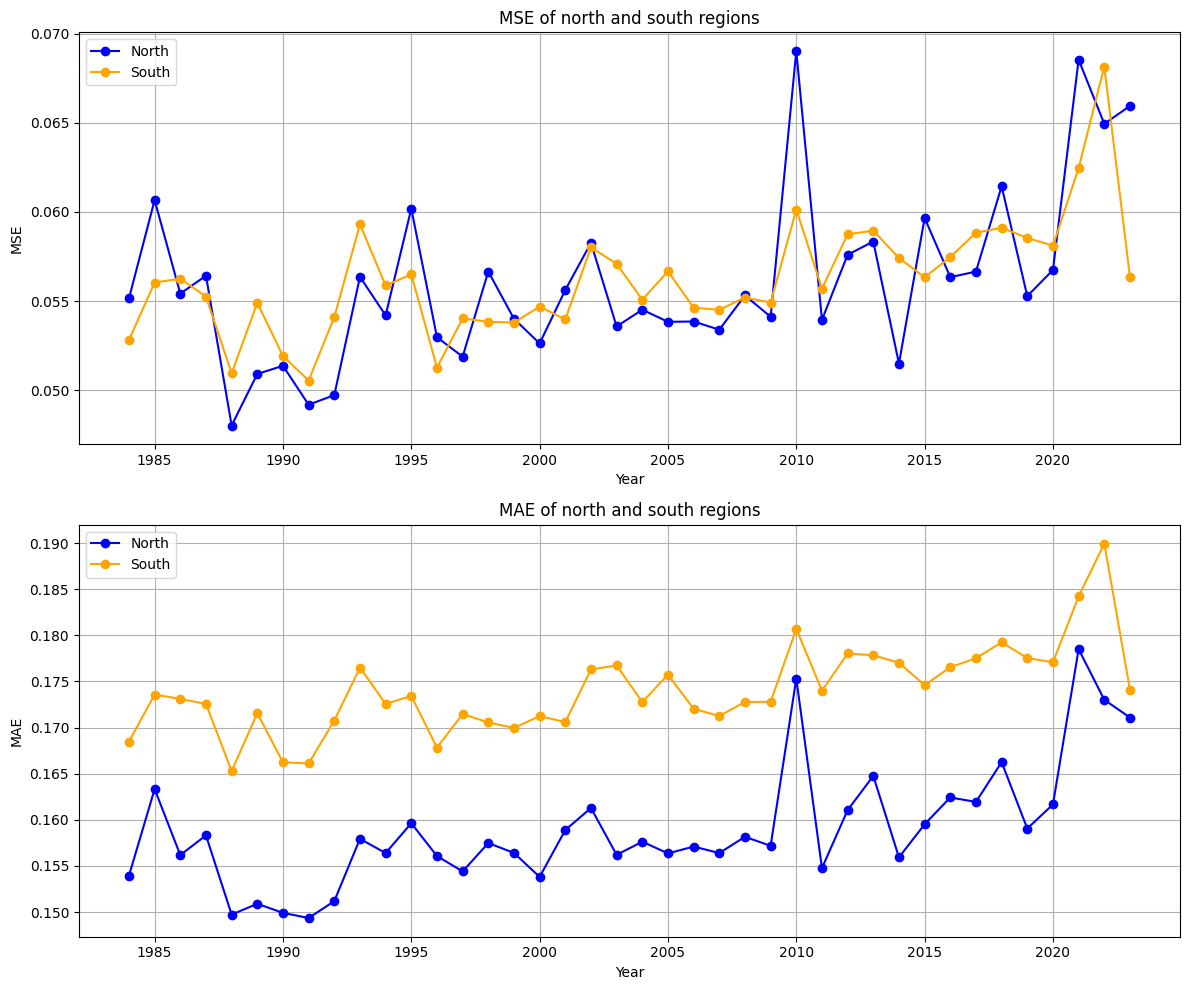

In [11]:
plot_metrics_over_time(years, mse_north, mse_south, mae_north, mae_south)



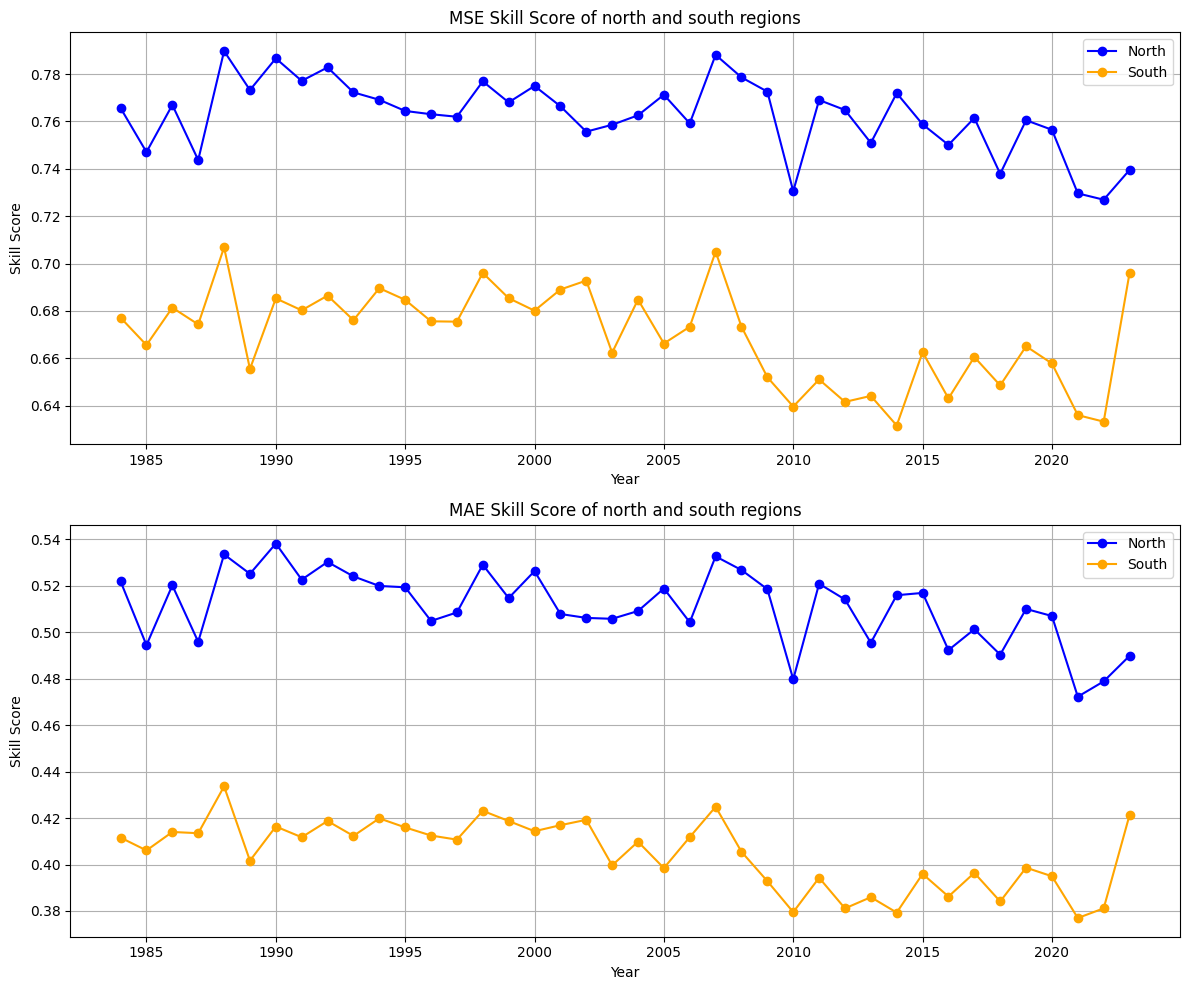

In [12]:
compare_skill_score(years, mse_skill_scores_north, mse_skill_scores_south, mae_skill_scores_north, mae_skill_scores_south)

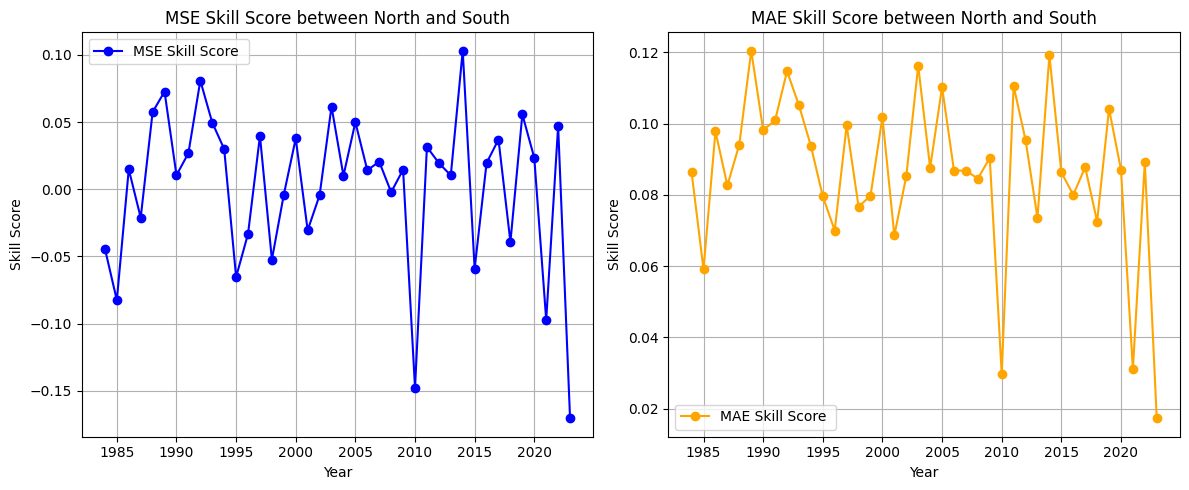

In [13]:
# get skill score between north and south

def north_south_skill_score(mse_north, mse_south, mae_north, mae_south):
    mse_skill_score = []
    mae_skill_score = []
    for i in range(len(mse_north['EDSR'])):
        mse_skill_score.append(get_skill_score(mse_north['EDSR'][i], mse_south['EDSR'][i]))
        mae_skill_score.append(get_skill_score(mae_north['EDSR'][i], mae_south['EDSR'][i]))
    return mse_skill_score, mae_skill_score

mse_skill_score2, mae_skill_score2 = north_south_skill_score(mse_north, mse_south, mae_north, mae_south)
plot_skill_scores(years, mse_skill_score2, mae_skill_score2)

In [14]:
top_percentile_mae = {"north": [], "south": []}
bias_per_year = {"north": [], "south": [], "north_90th": [], "south_90th": []}
for year in years:
    north_gt = ws_dict_north[year]['Ground Truth']
    south_gt = ws_dict_south[year]['Ground Truth']
    north_edsr = ws_dict_north[year]['EDSR']
    south_edsr = ws_dict_south[year]['EDSR']
    mask_north = np.where(north_gt > np.percentile(north_gt, 90))
    mask_south = np.where(south_gt > np.percentile(south_gt, 90))
    
    top_percentile_mae["north"].append(mae(north_edsr[mask_north], north_gt[mask_north]))
    top_percentile_mae["south"].append(mae(south_edsr[mask_south], south_gt[mask_south]))
    
    
    bias_per_year["north"].append((north_edsr - north_gt).mean())   
    bias_per_year["south"].append((south_edsr - south_gt).mean())
    bias_per_year["north_90th"].append((north_edsr[mask_north] - north_gt[mask_north]).mean())
    bias_per_year["south_90th"].append((south_edsr[mask_south] - south_gt[mask_south]).mean())

/tmp/ipykernel_9460/4021077455.py:52: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return (np.abs(pred - target)).mean()
/tmp/ipykernel_9460/3346114562.py:15: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  bias_per_year["north"].append((north_edsr - north_gt).mean())
/tmp/ipykernel_9460/3346114562.py:16: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  bias_per_year["south"].append((south_edsr - south_gt).mean())
/tmp/ipykernel_9460/3346114562.py:17: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  bias_per_year["north_90th"].append((north_edsr[mask_north] - north_gt[mask_north]).mean())
/tmp/ipykernel_9460/3346114562.py:18: Depre

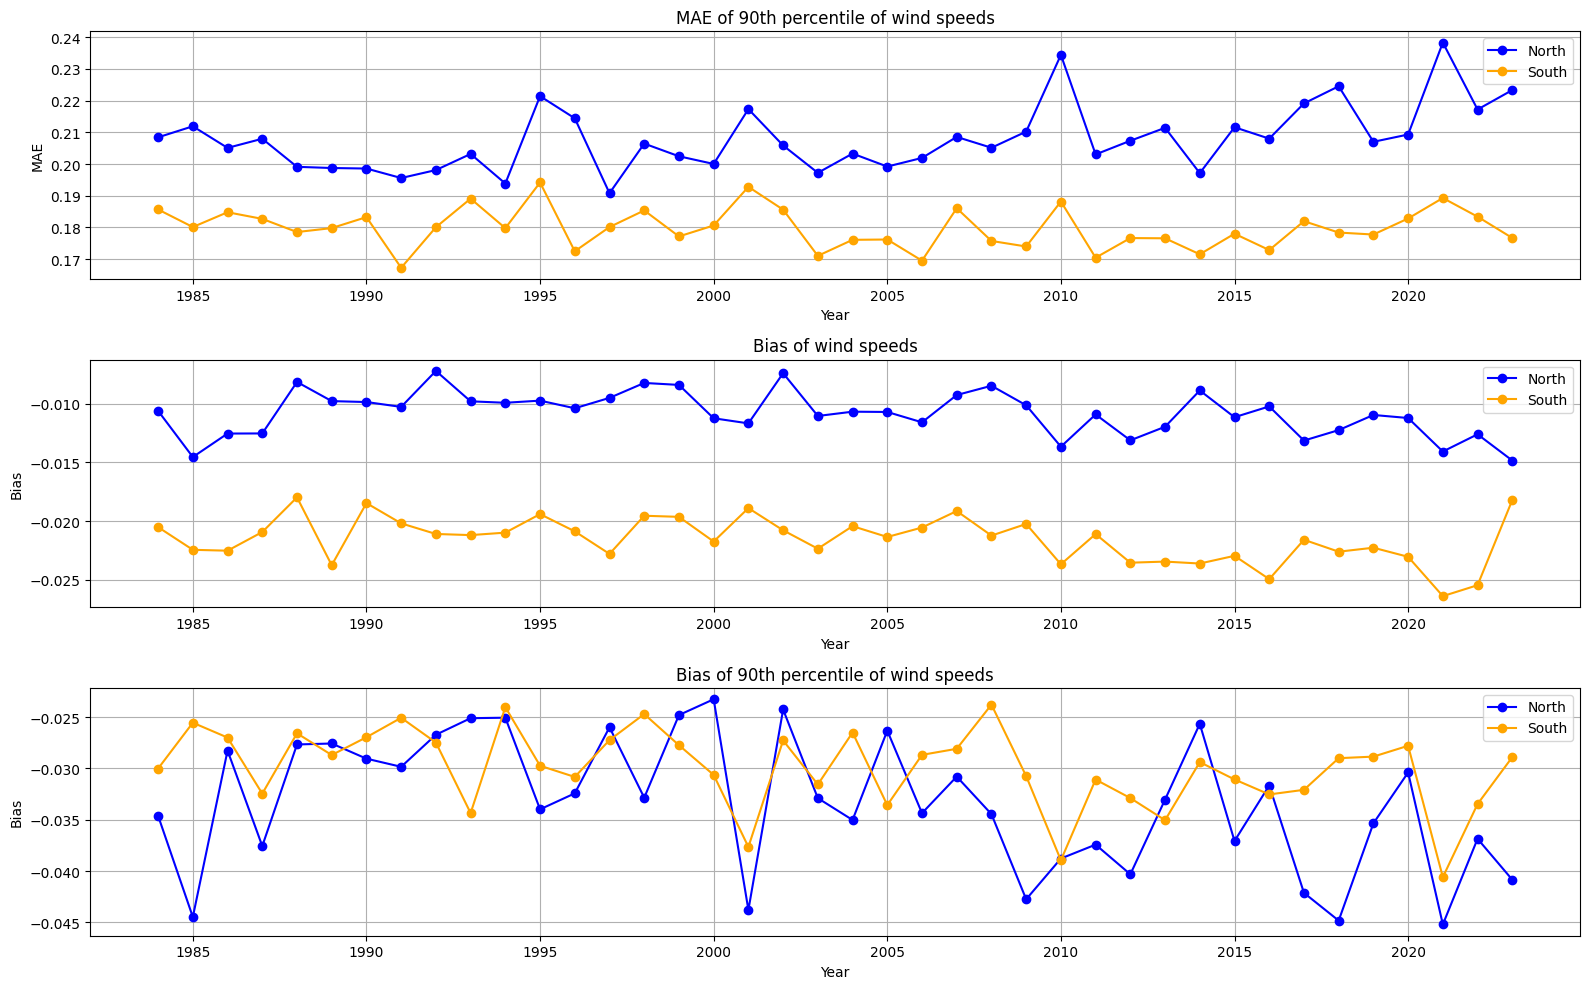

In [15]:
fig, ax = plt.subplots(3,1, figsize=(16, 10))
ax[0].plot(years, top_percentile_mae["north"], 'o-', label='North', color='blue')
ax[0].plot(years, top_percentile_mae["south"], 'o-', label='South', color='orange')
ax[0].set_title('MAE of 90th percentile of wind speeds')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('MAE')
ax[0].legend()
ax[0].grid(True)

ax[1].plot(years, bias_per_year["north"], 'o-', label='North', color='blue')
ax[1].plot(years, bias_per_year["south"], 'o-', label='South', color='orange')
ax[1].set_title('Bias of wind speeds')
ax[1].set_xlabel('Year')
ax[1].set_ylabel('Bias')
ax[1].legend()
ax[1].grid(True)

ax[2].plot(years, bias_per_year["north_90th"], 'o-', label='North', color='blue')
ax[2].plot(years, bias_per_year["south_90th"], 'o-', label='South', color='orange')
ax[2].set_title('Bias of 90th percentile of wind speeds')
ax[2].set_xlabel('Year')
ax[2].set_ylabel('Bias')
ax[2].legend()
ax[2].grid(True)
plt.tight_layout()
plt.show()


In [16]:
land_sea_geo_data = load_dataset("../../data/land_sea_merged.nc", start="1980", end="2023", patch_size=32)

land_sea_masks = land_sea_geo_data['lsm']
geopotentials = land_sea_geo_data['z']

In [17]:
# split data by year
land_sea_masks = land_sea_masks.sel(valid_time=slice('1984', '2023'))
geopotentials = geopotentials.sel(valid_time=slice('1984', '2023'))

ls_mask_by_year = land_sea_masks.groupby('valid_time.year')
geo_by_year = geopotentials.groupby('valid_time.year')

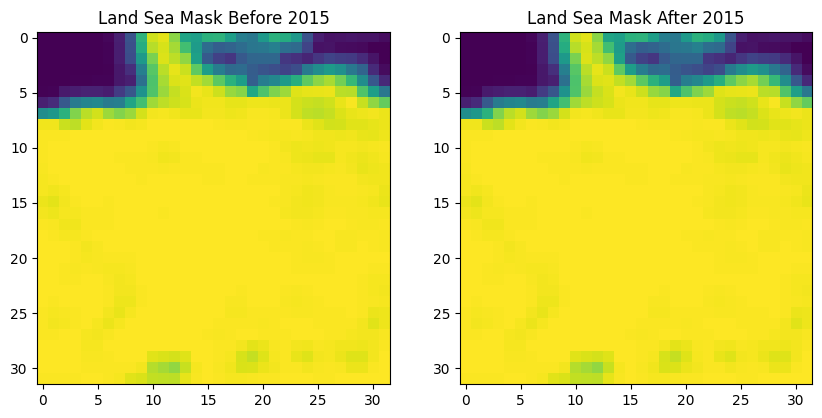

In [18]:
ls_mask_per_year = {year: group.values for year, group in ls_mask_by_year}
geo_per_year = {year: group.values for year, group in geo_by_year}


land_sea_mask_old = ls_mask_by_year[TEST_YEAR][0]
land_sea_mask_new = ls_mask_by_year[2016][0]


#Before 2015: val <= 0.5 is ocean, val > 0.5 is land
#After 2015: val <= 0.5 is water, including lakes , val > 0.5 is mixture of land and water but no ocean
# is independent of time so we can use the same mask for all years
fig, ax = plt.subplots(1, 2, figsize=(10, 6))
ax[0].imshow(land_sea_mask_old)
ax[0].set_title('Land Sea Mask Before 2015')
ax[1].imshow(land_sea_mask_new)
ax[1].set_title('Land Sea Mask After 2015')
plt.show()

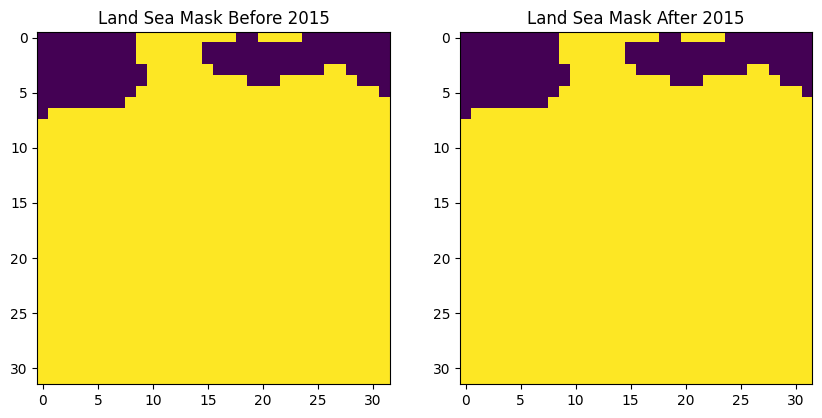

In [19]:
land_sea_mask_old = land_sea_mask_old > 0.5
land_sea_mask_new = land_sea_mask_new > 0.5

fig, ax = plt.subplots(1, 2, figsize=(10, 6))
ax[0].imshow(land_sea_mask_old)
ax[0].set_title('Land Sea Mask Before 2015')
ax[1].imshow(land_sea_mask_new)
ax[1].set_title('Land Sea Mask After 2015')
plt.show()


In [20]:
land_sea_mask = ls_mask_by_year[2023][0]
land_sea_mask = land_sea_mask > 0.5
print(land_sea_mask.shape)
print(land_sea_mask_old.shape)

(32, 32)
(32, 32)


(array([180.,  63.,  58.,  49.,  46.,  27.,  17.,   9.,  11.,   7.,   9.,
          7.,   5.,  11.,  19.,   8.,  10.,  11.,  16.,  20.,   9.,  22.,
         29.,  22.,  19.,  12.,  18.,  11.,  13.,  20.,  21.,  14.,  26.,
         17.,  17.,  13.,  15.,   9.,  11.,  14.,   9.,   8.,   5.,   9.,
          7.,   5.,   1.,   8.,   8.,   2.,   1.,   8.,   0.,   2.,   0.,
          0.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,   1.,   1.,   4.,
          5.,   1.,   1.,   0.,   1.,   0.,   0.,   0.,   0.,   1.,   1.,
          1.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   2.,   1.,   2.,   3.,   2.,   3.,   1.,   0.,   2.,
          1.]),
 array([-1.21484065e+00,  1.32544184e+01,  2.77236786e+01,  4.21929359e+01,
         5.66621971e+01,  7.11314545e+01,  8.56007080e+01,  1.00069969e+02,
         1.14539230e+02,  1.29008484e+02,  1.43477753e+02,  1.57947006e+02,
         1.72416260e+02,  1.86885529e+02,  2.01354782e+02,  2.15824051e+02,
         2.302

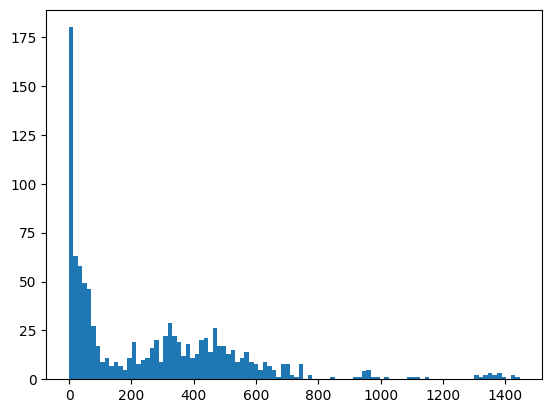

In [21]:
gravitational_acceleration = 9.80665

geo_height = geo_by_year[2023][0] / gravitational_acceleration # independent of time

plt.hist(np.array(geo_height).flatten(), bins=100)


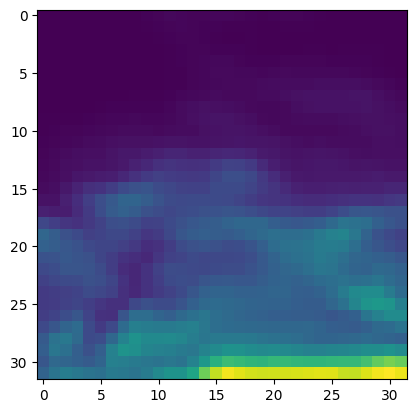

In [22]:
plt.imshow(geo_height)

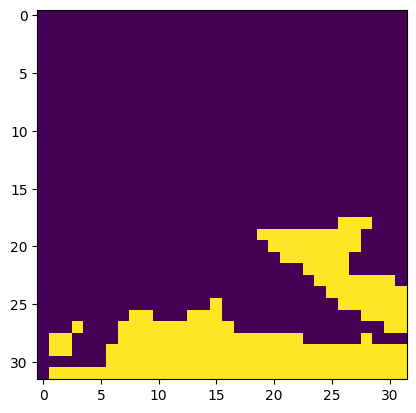

In [23]:
geo_height_mask = geo_height > 500

plt.imshow(geo_height_mask)

In [24]:
land_sea_mask = land_sea_mask.values
geo_height_mask = geo_height_mask.values

In [25]:
land_ws_dicts = {year: {} for year in years}
sea_ws_dicts = {year: {} for year in years}
flat_ws_dicts = {year: {} for year in years}
mountain_ws_dicts = {year: {} for year in years}

#masks to numpy arrays

for year in years:
    if year not in ws_dict_total:
        continue
    
    for key in ws_dict_total[year].keys():
        ws = ws_dict_total[year][key]
        
        land_ws_dicts[year][key] = ws * land_sea_mask[np.newaxis, :, :]
        sea_ws_dicts[year][key] = ws * ~land_sea_mask[np.newaxis, :, :] 
        flat_ws_dicts[year][key] = ws * geo_height_mask[np.newaxis, :, :]   
        mountain_ws_dicts[year][key] = ws * ~geo_height_mask[np.newaxis, :, :]
        

/tmp/ipykernel_9460/3795333522.py:15: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  land_ws_dicts[year][key] = ws * land_sea_mask[np.newaxis, :, :]
/tmp/ipykernel_9460/3795333522.py:16: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  sea_ws_dicts[year][key] = ws * ~land_sea_mask[np.newaxis, :, :]
/tmp/ipykernel_9460/3795333522.py:17: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  flat_ws_dicts[year][key] = ws * geo_height_mask[np.newaxis, :, :]
/tmp/ipykernel_9460/3795333522.py:18: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  mountain_ws_dicts[year][key] = ws * ~geo_height_mask[np.newaxis, :, :]


In [26]:
mse_land, mae_land, mse_skill_scores_land, mae_skill_scores_land = get_metrics_over_time(years, land_ws_dicts)
mse_sea, mae_sea, mse_skill_scores_sea, mae_skill_scores_sea = get_metrics_over_time(years, sea_ws_dicts)
mse_flat, mae_flat, mse_skill_scores_flat, mae_skill_scores_flat = get_metrics_over_time(years, flat_ws_dicts)
mse_mountain, mae_mountain, mse_skill_scores_mountain, mae_skill_scores_mountain = get_metrics_over_time(years, mountain_ws_dicts)

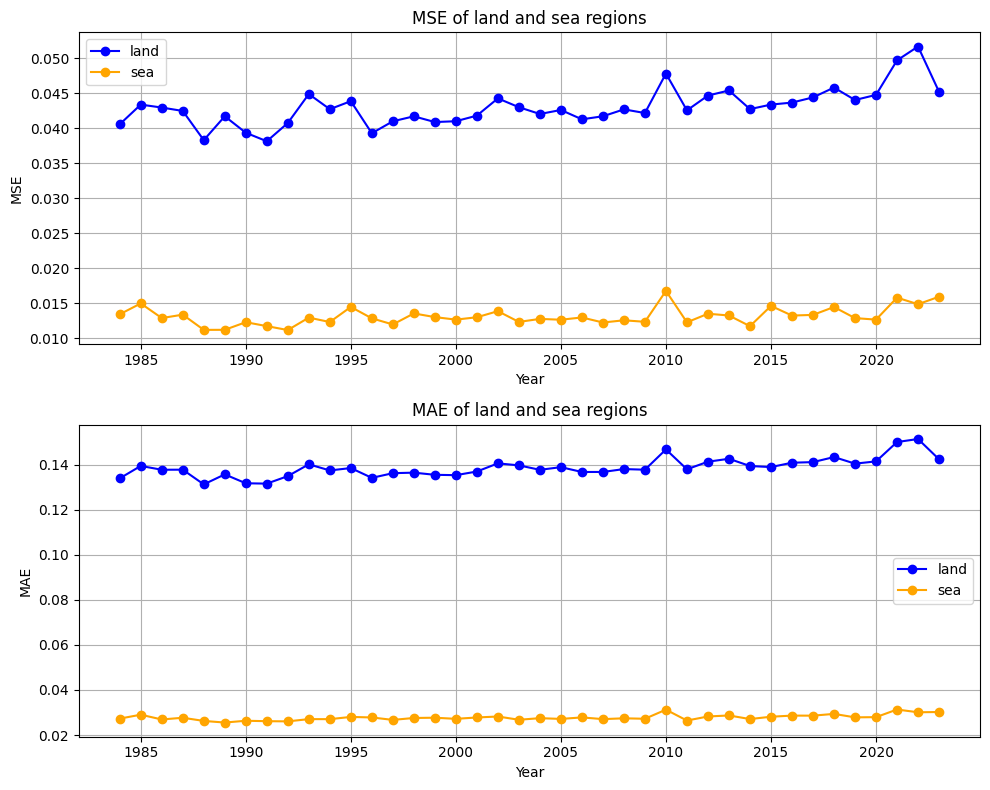

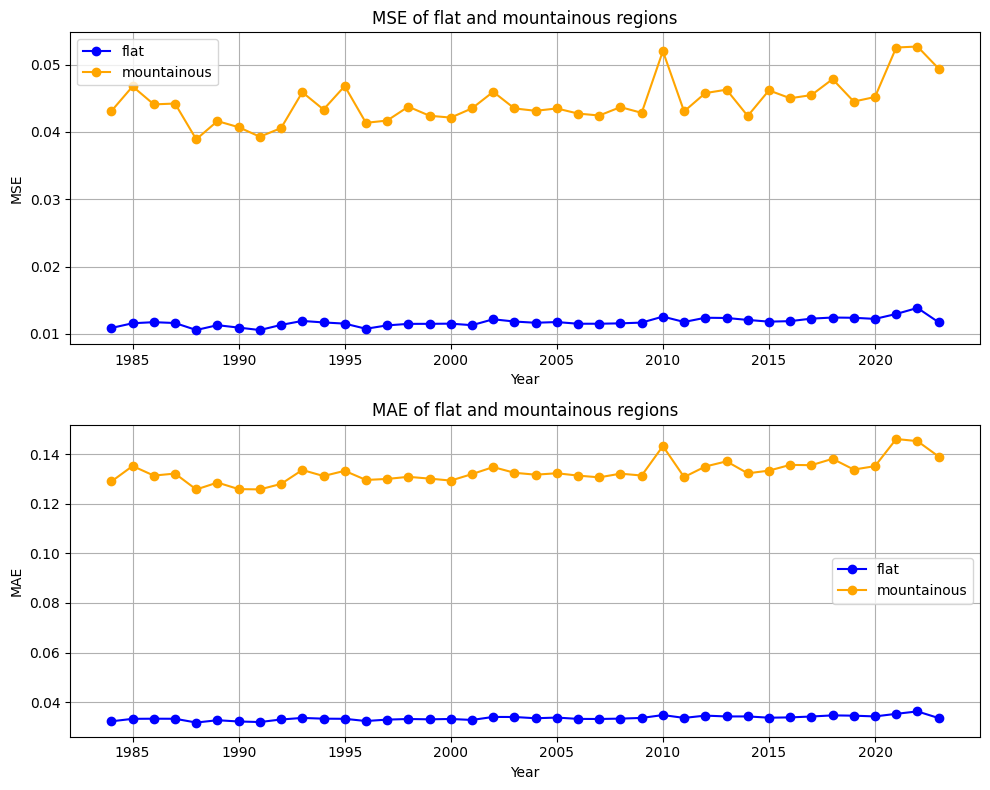

In [27]:
#plot land and sea and flat and mountain separately
plot_metrics_over_time2(years, mse_land, mse_sea, mae_land, mae_sea, 'land', 'sea')
plot_metrics_over_time2(years, mse_flat, mse_mountain, mae_flat, mae_mountain, 'flat', 'mountainous')


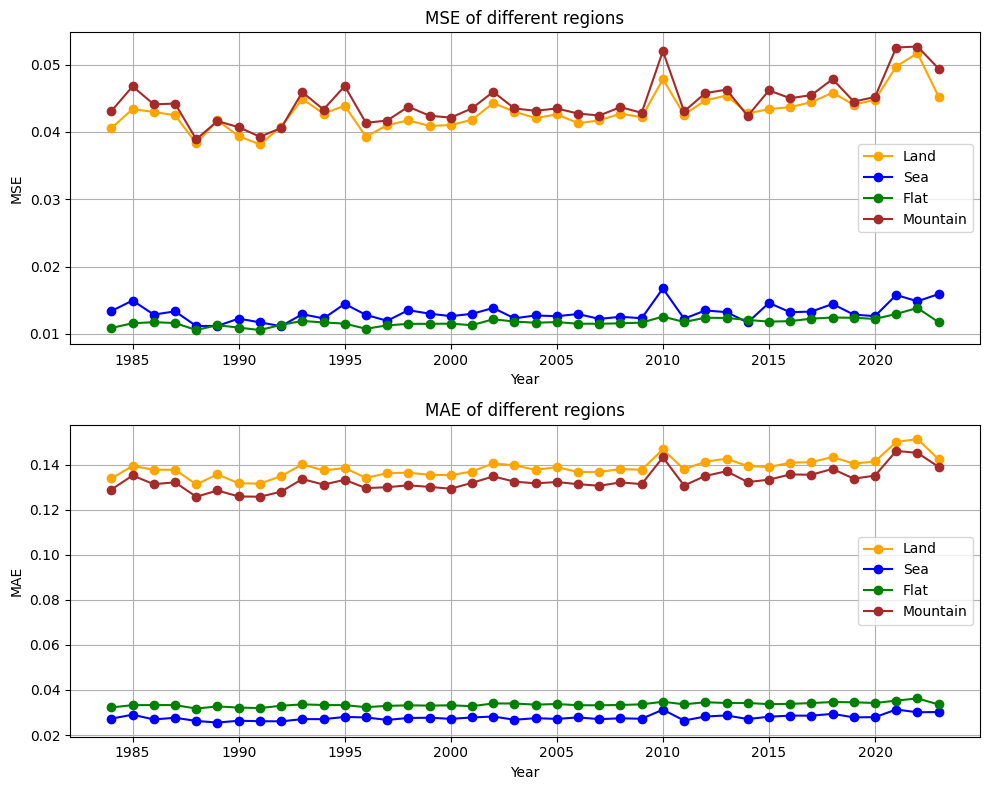

In [28]:
# plot all mses and maes in one 1x2 plot
fig, ax = plt.subplots(2, 1, figsize=(10, 8))
ax[0].plot(years, mse_land['EDSR'], 'o-', label='Land', color='orange')
ax[0].plot(years, mse_sea['EDSR'], 'o-', label='Sea', color='blue')
ax[0].plot(years, mse_flat['EDSR'], 'o-', label='Flat', color='green')
ax[0].plot(years, mse_mountain['EDSR'], 'o-', label='Mountain', color='brown')
ax[0].set_title('MSE of different regions')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('MSE')
ax[0].legend()
ax[0].grid(True)
ax[1].plot(years, mae_land['EDSR'], 'o-', label='Land', color='orange')
ax[1].plot(years, mae_sea['EDSR'], 'o-', label='Sea', color='blue')
ax[1].plot(years, mae_flat['EDSR'], 'o-', label='Flat', color='green')
ax[1].plot(years, mae_mountain['EDSR'], 'o-', label='Mountain', color='brown')
ax[1].set_title('MAE of different regions')
ax[1].set_xlabel('Year')
ax[1].set_ylabel('MAE')
ax[1].legend()
ax[1].grid(True)
plt.tight_layout()
plt.show()



Slope: 0.0002, 
Intercept: -0.2592, 
R-value: 0.6510, 
P-value: 0.00000541, 
Std. Error: 0.0000


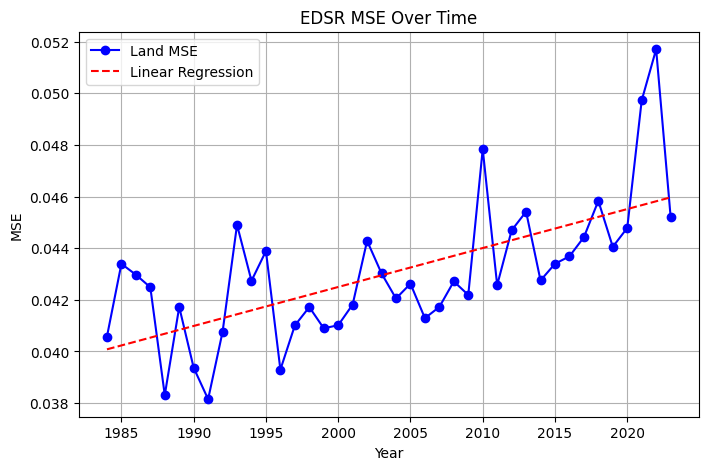

In [29]:
# linear regression for all four
from scipy.stats import linregress

slope, intercept, r_value, p_value, std_err = linregress(years, mse_land['EDSR'])

print(f"Slope: {slope:.4f}, \nIntercept: {intercept:.4f}, \nR-value: {r_value:.4f}, \nP-value: {p_value:.8f}, \nStd. Error: {std_err:.4f}")

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(years, mse_land['EDSR'], 'o-', label='Land MSE', color='blue')
ax.plot(years, slope * np.array(years) + intercept, '--', label='Linear Regression', color='red')
ax.set_title('EDSR MSE Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('MSE')
ax.legend()
ax.grid(True)
plt.show()


 

Slope: 0.0000, 
Intercept: -0.0753, 
R-value: 0.4038, 
P-value: 0.00976116, 
Std. Error: 0.0000


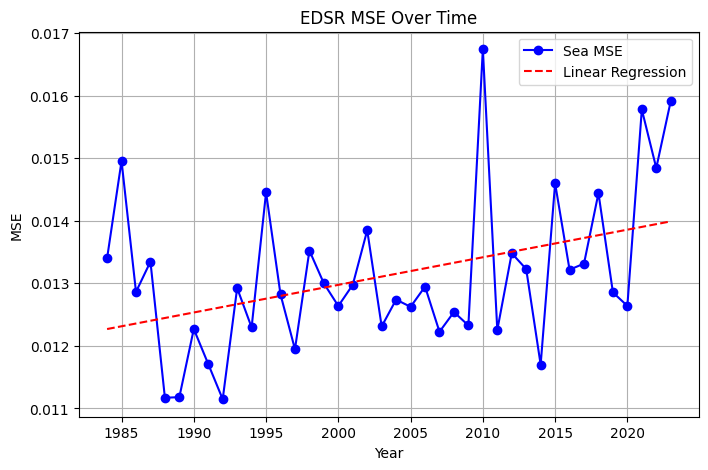

In [30]:
slope, intercept, r_value, p_value, std_err = linregress(years, mse_sea['EDSR'])

print(f"Slope: {slope:.4f}, \nIntercept: {intercept:.4f}, \nR-value: {r_value:.4f}, \nP-value: {p_value:.8f}, \nStd. Error: {std_err:.4f}")

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(years, mse_sea['EDSR'], 'o-', label='Sea MSE', color='blue')
ax.plot(years, slope * np.array(years) + intercept, '--', label='Linear Regression', color='red')
ax.set_title('EDSR MSE Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('MSE')
ax.legend()
ax.grid(True)
plt.show()

Slope: 0.0000, 
Intercept: -0.0662, 
R-value: 0.7207, 
P-value: 0.00000016, 
Std. Error: 0.0000


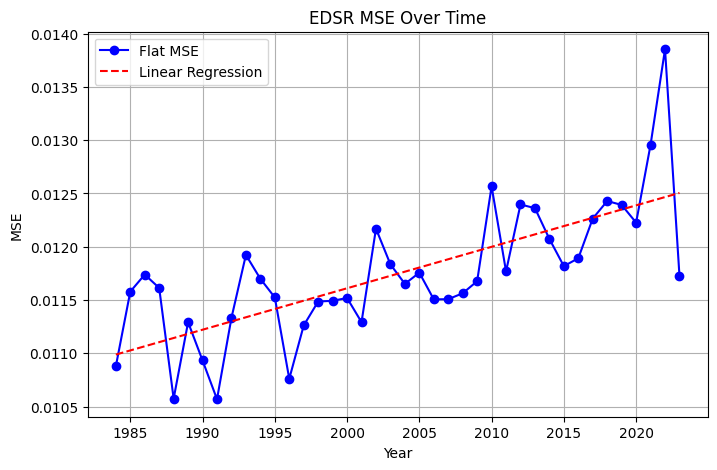

In [33]:
slope, intercept, r_value, p_value, std_err = linregress(years, mse_flat['EDSR'])

print(f"Slope: {slope:.4f}, \nIntercept: {intercept:.4f}, \nR-value: {r_value:.4f}, \nP-value: {p_value:.8f}, \nStd. Error: {std_err:.4f}")

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(years, mse_flat['EDSR'], 'o-', label='Flat MSE', color='blue')
ax.plot(years, slope * np.array(years) + intercept, '--', label='Linear Regression', color='red')
ax.set_title('EDSR MSE Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('MSE')
ax.legend()
ax.grid(True)
plt.show()

Slope: 0.0002, 
Intercept: -0.2683, 
R-value: 0.5714, 
P-value: 0.00011768, 
Std. Error: 0.0000


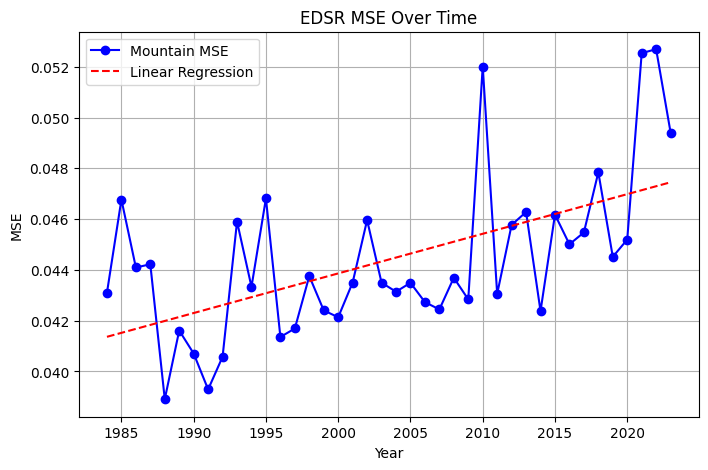

In [32]:
slope, intercept, r_value, p_value, std_err = linregress(years, mse_mountain['EDSR'])

print(f"Slope: {slope:.4f}, \nIntercept: {intercept:.4f}, \nR-value: {r_value:.4f}, \nP-value: {p_value:.8f}, \nStd. Error: {std_err:.4f}")

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(years, mse_mountain['EDSR'], 'o-', label='Mountain MSE', color='blue')
ax.plot(years, slope * np.array(years) + intercept, '--', label='Linear Regression', color='red')
ax.set_title('EDSR MSE Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('MSE')
ax.legend()
ax.grid(True)
plt.show()